<center><ins><h1>Data Statistics</h1></ins></center>

###### **Author:** Cedric Hering-Peter
###### **Address:** AG Schulz / Botantical Institut / Am Botanischen Garten 5 / 24118 Kiel

# Imports

In [200]:

# System
import os, sys

# Packages
import pandas as pd
import numpy as np
from scripts import data_helper, plot_helper
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.weightstats import ttest_ind
#import pylab

# Further statistics
import statsmodels.stats.api as sms
import scikit_posthocs as sp

# Variables

In [201]:

# Show numeric output in decimal format e.g., 2.1514
pd.options.display.float_format = '{:,.2f}'.format

# Raw Data Import

In [202]:
# Get all raw data files
rec_rat = pd.read_csv(data_helper.get_output_path(CONFIG, "Raw-Data/Recovery-Rates_Raw-Data.csv")"))
sin_vel = pd.read_csv(data_helper.get_output_path(CONFIG, "Raw-Data/Sinking-Velocities_Raw-Data.csv")"))
par_siz = pd.read_csv(data_helper.get_output_path(CONFIG, "Raw-Data/Particle-Sizes_Raw-Data.csv")"))
sus_sol = pd.read_csv(data_helper.get_output_path(CONFIG, "Raw-Data/Suspended-Solids_Raw-Data.csv")"))
zet_pot = pd.read_csv(data_helper.get_output_path(CONFIG, "Raw-Data/Zeta-Potential_Raw-Data.csv")"))

# Average techniquel replicates of zeta potentials
zet_tec_rep_mean = zet_pot.groupby(["ID", "EXPERIMENT_NAME", "SAMPLE_NAME", "TIME", "BIO_REP"], as_index = False).agg({"ZETA_POTENTIAL_MV": pd.Series.mean})
zet_tec_rep_mean.drop(zet_tec_rep_mean[zet_tec_rep_mean["EXPERIMENT_NAME"].str.contains("Control")].index, inplace = True)
zet_tec_rep_mean.drop(zet_tec_rep_mean[zet_tec_rep_mean["SAMPLE_NAME"] == "+EPS"].index, inplace = True)
zet_pot = zet_tec_rep_mean.sort_values(by = ["EXPERIMENT_NAME", "TIME", "SAMPLE_NAME", "BIO_REP"], ignore_index = True)

sus_sol = pd.read_csv(data_helper.get_output_path(CONFIG, "Raw-Data/Suspended-Solids_Raw-Data.csv")"))
sus_sol.drop(sus_sol[sus_sol["SAMPLE_NAME"] == "+EPS"].index, inplace = True)
sus_sol = sus_sol.sort_values(by = ["EXPERIMENT_NAME", "TIME", "SAMPLE_NAME", "BIO_REP"], ignore_index = True)


# Merge into dataframe with all categories
merged_df = pd.concat([rec_rat["ID"], rec_rat["EXPERIMENT_NAME"], rec_rat["SAMPLE_NAME"], rec_rat["TIME"], 
                       rec_rat["RRATE_%"], 
                       sin_vel["MEAN_SVELO_M/H"], 
                       par_siz["GEOMETRIC.MEAN"],
                       sus_sol["TSS_g/L"],
                       sus_sol["TSS_%"],
                       sus_sol["VSS_g/L"],
                       sus_sol["VSS_%"],
                       zet_pot["ZETA_POTENTIAL_MV"],
                       ], axis = 1)
merged_df.rename(columns = {"GEOMETRIC.MEAN": "MEAN_PARSIZE_µM"}, inplace = True)
merged_df.head()

,ID,EXPERIMENT_NAME,SAMPLE_NAME,TIME,RRATE_%,MEAN_SVELO_M/H,MEAN_PARSIZE_µM,TSS_g/L,TSS_%,VSS_g/L,VSS_%,ZETA_POTENTIAL_MV
0,CH230710,AT,0.1,0,87.71,2.51,632.67,1.29,95.23,0.06,4.77,-35.33
1,CH230802,AT,0.1,0,91.62,3.15,981.62,1.10,94.36,0.06,5.64,-18.23
2,CH230907,AT,0.1,0,83.62,1.99,728.29,1.29,95.18,0.06,4.82,-30.27
3,CH230710,AT,1,0,87.71,2.51,632.67,1.29,95.23,0.06,4.77,-35.33
4,CH230802,AT,1,0,91.62,3.15,981.62,1.10,94.36,0.06,5.64,-18.23


In [ ]:
# file = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/TTest-Data.csv")
# if(os.path.exists(file) and os.path.isfile(file)): 
#   os.remove(file) 
#   print("File deleted.") 
# else: 
#   print("File not found.")       

# file = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/One-Way-ANOVA-Data.csv")
# if(os.path.exists(file) and os.path.isfile(file)): 
#   os.remove(file) 
#   print("File deleted.") 
# else: 
#   print("File not found.")
  
# file = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/Two-Way-ANOVA-Data.csv")
# if(os.path.exists(file) and os.path.isfile(file)): 
#   os.remove(file) 
#   print("File deleted.") 
# else: 
#   print("File not found.")

File deleted.
File deleted.
File deleted.


# T-Test SC Experiment (obsolet)

In [204]:
ttest_df = pd.DataFrame(data_helper.filter(merged_df, time = [12]))

# Filter through each sample and compare it against Algaemix
sc_exp = ttest_df[ttest_df["EXPERIMENT_NAME"] == "SC"]
for sam in sc_exp["SAMPLE_NAME"].unique():
    algaemix = sc_exp[sc_exp["SAMPLE_NAME"] == "Algaemix"]
    cur_sam = sc_exp[sc_exp["SAMPLE_NAME"] == sam]
    
    # Perform static t-Tests
    recrat_ttest = ttest_ind(algaemix["RRATE_%"], cur_sam["RRATE_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
    sinvel_ttest = ttest_ind(algaemix["MEAN_SVELO_M/H"], cur_sam["MEAN_SVELO_M/H"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
    parsiz_ttest = ttest_ind(algaemix["MEAN_PARSIZE_µM"], cur_sam["MEAN_PARSIZE_µM"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
    TSSabs_ttest = ttest_ind(algaemix["TSS_g/L"], cur_sam["TSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
    TSSrel_ttest = ttest_ind(algaemix["TSS_%"], cur_sam["TSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
    VSSabs_ttest = ttest_ind(algaemix["VSS_g/L"], cur_sam["VSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
    VSSrel_ttest = ttest_ind(algaemix["VSS_%"], cur_sam["VSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
    zetpot_ttest = ttest_ind(algaemix["ZETA_POTENTIAL_MV"], cur_sam["ZETA_POTENTIAL_MV"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
    
    # Create results dataframe and insert data
    sam_results = pd.DataFrame()
    sam_results.insert(0, column = "SC" + " " + "MMCvs" + sam, value = ["tstat", "pvalue", "df"])
    sam_results = pd.concat([sam_results, pd.Series(recrat_ttest, name = "RRATE_%"),
                                            pd.Series(sinvel_ttest, name = "MEAN_SVELO_M/H"),
                                            pd.Series(parsiz_ttest, name = "MEAN_PARSIZE_µM"),
                                            pd.Series(TSSabs_ttest, name = "TSS_g/L"),
                                            pd.Series(TSSrel_ttest, name = "TSS_%"),
                                            pd.Series(VSSabs_ttest, name = "VSS_g/L"),
                                            pd.Series(VSSrel_ttest, name = "TSS_%"),
                                            pd.Series(zetpot_ttest, name = "ZETA_POTENTIAL_MV")], axis = 1)

    # Export T-Test from 0 - 48 hours to csv-file (append)
    file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/TTest-Data.csv")
    sam_results.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a")

# T-Test CC Experiment (obsolet)

In [205]:
# Filter CC samples
sc_exp = ttest_df[ttest_df["EXPERIMENT_NAME"] == "CC"]
femak = sc_exp[sc_exp["SAMPLE_NAME"] == "FEMAK"]
oecd = sc_exp[sc_exp["SAMPLE_NAME"] == "OECD"]
ruebio = sc_exp[sc_exp["SAMPLE_NAME"] == "RueBio"]

# Perform static t-Tests femak against oecd
recrat_ttest = ttest_ind(femak["RRATE_%"], oecd["RRATE_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
sinvel_ttest = ttest_ind(femak["MEAN_SVELO_M/H"], oecd["MEAN_SVELO_M/H"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
parsiz_ttest = ttest_ind(femak["MEAN_PARSIZE_µM"], oecd["MEAN_PARSIZE_µM"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
TSSabs_ttest = ttest_ind(femak["TSS_g/L"], oecd["TSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
TSSrel_ttest = ttest_ind(femak["TSS_%"], oecd["TSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
VSSabs_ttest = ttest_ind(femak["VSS_g/L"], oecd["VSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
VSSrel_ttest = ttest_ind(femak["VSS_%"], oecd["VSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
zetpot_ttest = ttest_ind(femak["ZETA_POTENTIAL_MV"], oecd["ZETA_POTENTIAL_MV"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)

# Create results dataframe and insert data
sam_results = pd.DataFrame()
sam_results.insert(0, column = "CC" + " " + "FEMAKvsOECD", value = ["tstat", "pvalue", "df"])
sam_results = pd.concat([sam_results, pd.Series(recrat_ttest, name = "RRATE_%"),
                                        pd.Series(sinvel_ttest, name = "MEAN_SVELO_M/H"),
                                        pd.Series(parsiz_ttest, name = "MEAN_PARSIZE_µM"),
                                        pd.Series(TSSabs_ttest, name = "TSS_g/L"),
                                        pd.Series(TSSrel_ttest, name = "TSS_%"),
                                        pd.Series(VSSabs_ttest, name = "VSS_g/L"),
                                        pd.Series(VSSrel_ttest, name = "TSS_%"),
                                        pd.Series(zetpot_ttest, name = "ZETA_POTENTIAL_MV")], axis = 1)

# Export T-Test from 0 - 48 hours to csv-file (append)
file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/TTest-Data.csv")
sam_results.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a")

# Perform static t-Tests femak against ruebio
recrat_ttest = ttest_ind(femak["RRATE_%"], ruebio["RRATE_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
sinvel_ttest = ttest_ind(femak["MEAN_SVELO_M/H"], ruebio["MEAN_SVELO_M/H"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
parsiz_ttest = ttest_ind(femak["MEAN_PARSIZE_µM"], ruebio["MEAN_PARSIZE_µM"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
TSSabs_ttest = ttest_ind(femak["TSS_g/L"], ruebio["TSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
TSSrel_ttest = ttest_ind(femak["TSS_%"], ruebio["TSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
VSSabs_ttest = ttest_ind(femak["VSS_g/L"], ruebio["VSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
VSSrel_ttest = ttest_ind(femak["VSS_%"], ruebio["VSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
zetpot_ttest = ttest_ind(femak["ZETA_POTENTIAL_MV"], ruebio["ZETA_POTENTIAL_MV"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)

# Create results dataframe and insert data
sam_results = pd.DataFrame()
sam_results.insert(0, column = "CC" + " " + "FEMAKvsRueBio", value = ["tstat", "pvalue", "df"])
sam_results = pd.concat([sam_results, pd.Series(recrat_ttest, name = "RRATE_%"),
                                        pd.Series(sinvel_ttest, name = "MEAN_SVELO_M/H"),
                                        pd.Series(parsiz_ttest, name = "MEAN_PARSIZE_µM"),
                                        pd.Series(TSSabs_ttest, name = "TSS_g/L"),
                                        pd.Series(TSSrel_ttest, name = "TSS_%"),
                                        pd.Series(VSSabs_ttest, name = "VSS_g/L"),
                                        pd.Series(VSSrel_ttest, name = "TSS_%"),
                                        pd.Series(zetpot_ttest, name = "ZETA_POTENTIAL_MV")], axis = 1)

# Export T-Test from 0 - 48 hours to csv-file (append)
file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/TTest-Data.csv")
sam_results.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a")

# Perform static t-Tests oecd against ruebio
recrat_ttest = ttest_ind(oecd["RRATE_%"], ruebio["RRATE_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
sinvel_ttest = ttest_ind(oecd["MEAN_SVELO_M/H"], ruebio["MEAN_SVELO_M/H"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
parsiz_ttest = ttest_ind(oecd["MEAN_PARSIZE_µM"], ruebio["MEAN_PARSIZE_µM"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
TSSabs_ttest = ttest_ind(oecd["TSS_g/L"], ruebio["TSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
TSSrel_ttest = ttest_ind(oecd["TSS_%"], ruebio["TSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
VSSabs_ttest = ttest_ind(oecd["VSS_g/L"], ruebio["VSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
VSSrel_ttest = ttest_ind(oecd["VSS_%"], ruebio["VSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
zetpot_ttest = ttest_ind(oecd["ZETA_POTENTIAL_MV"], ruebio["ZETA_POTENTIAL_MV"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)

# Create results dataframe and insert data
sam_results = pd.DataFrame()
sam_results.insert(0, column = "CC" + " " + "OECDvsRueBio", value = ["tstat", "pvalue", "df"])
sam_results = pd.concat([sam_results, pd.Series(recrat_ttest, name = "RRATE_%"),
                                        pd.Series(sinvel_ttest, name = "MEAN_SVELO_M/H"),
                                        pd.Series(parsiz_ttest, name = "MEAN_PARSIZE_µM"),
                                        pd.Series(TSSabs_ttest, name = "TSS_g/L"),
                                        pd.Series(TSSrel_ttest, name = "TSS_%"),
                                        pd.Series(VSSabs_ttest, name = "VSS_g/L"),
                                        pd.Series(VSSrel_ttest, name = "TSS_%"),
                                        pd.Series(zetpot_ttest, name = "ZETA_POTENTIAL_MV")], axis = 1)

# Export T-Test from 0 - 48 hours to csv-file (append)
file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/TTest-Data.csv")
sam_results.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a")

# T-Test Time-Sensitive Experiments (obsolet)

In [206]:
# Clean all unneeded experiment data 
ttest_df.drop(ttest_df[ttest_df["EXPERIMENT_NAME"] == "SC"].index, inplace = True)
ttest_df.drop(ttest_df[ttest_df["EXPERIMENT_NAME"] == "CC"].index, inplace = True)

# Filter through all left experiments and compare 48 hours against 0 hours
for exp in ttest_df["EXPERIMENT_NAME"].unique():
    subexp_df = ttest_df[ttest_df["EXPERIMENT_NAME"] == exp]
    for sam in subexp_df["SAMPLE_NAME"].unique():
        subsam_df = ttest_df[ttest_df["SAMPLE_NAME"] == sam]
        time0 = subsam_df[subsam_df["TIME"] == 0]
        #time24 = subsam_df[subsam_df["TIME"] == 24]
        time48 = subsam_df[subsam_df["TIME"] == 48]
        
        # Perform time-sensitive t-Tests
        recrat_ttest = ttest_ind(time0["RRATE_%"], time48["RRATE_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
        sinvel_ttest = ttest_ind(time0["MEAN_SVELO_M/H"], time48["MEAN_SVELO_M/H"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
        parsiz_ttest = ttest_ind(time0["MEAN_PARSIZE_µM"], time48["MEAN_PARSIZE_µM"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
        TSSabs_ttest = ttest_ind(time0["TSS_g/L"], time48["TSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
        TSSrel_ttest = ttest_ind(time0["TSS_%"], time48["TSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
        VSSabs_ttest = ttest_ind(time0["VSS_g/L"], time48["VSS_g/L"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
        VSSrel_ttest = ttest_ind(time0["VSS_%"], time48["VSS_%"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)
        zetpot_ttest = ttest_ind(time0["ZETA_POTENTIAL_MV"], time48["ZETA_POTENTIAL_MV"], alternative = "two-sided", usevar = "pooled", weights = (None, None), value = 0)

        # Create results dataframe and insert data
        sam_results = pd.DataFrame()
        sam_results.insert(0, column = exp + " " + sam + " 48to0", value = ["tstat", "pvalue", "df"])
        sam_results = pd.concat([sam_results, pd.Series(recrat_ttest, name = "RRATE_%"),
                                              pd.Series(sinvel_ttest, name = "MEAN_SVELO_M/H"),
                                              pd.Series(parsiz_ttest, name = "MEAN_PARSIZE_µM"),
                                              pd.Series(TSSabs_ttest, name = "TSS_g/L"),
                                              pd.Series(TSSrel_ttest, name = "TSS_%"),
                                              pd.Series(VSSabs_ttest, name = "VSS_g/L"),
                                              pd.Series(VSSrel_ttest, name = "TSS_%"),
                                              pd.Series(zetpot_ttest, name = "ZETA_POTENTIAL_MV")], axis = 1)

        # Export T-Test from 0 - 48 hours to csv-file
        file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/TTest-Data.csv")
        sam_results.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a")

/Users/cedric/Documents/Career/PhD-Student/Experiments/Data-Science/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:652: RuntimeWarning: invalid value encountered in scalar divide
  tstat = (value1 - value2 - diff) / std_diff


# One-Way ANOVA Special cases

In [207]:
owanova_df = pd.DataFrame(data_helper.filter(merged_df, time = [12]))

# One-Way ANOVA over Species Experiment
sc_exp = owanova_df[owanova_df["EXPERIMENT_NAME"] == "SC"]
for index in range(4, len(sc_exp.columns)):
    # Subset data and rename current method to TREATMENT for ANOVA structure
    cur_set = sc_exp.iloc[:, [0,1,2,3, index]]
    method = cur_set.columns[4] # save current method name
    cur_set.columns = ["ID", "EXPERIMENT_NAME", "SAMPLE_NAME", "TIME", "TREATMENT"] # rename treatment column
    
    # Perform one-way ANOVA
    model = ols('TREATMENT ~ C(SAMPLE_NAME)', data = cur_set).fit()
    sc_result = sm.stats.anova_lm(model, typ = 1)
    
    sc_result.index = [sc_exp.columns[index], "Residual"]
    sc_result.index.names = ["SC Experiment"]
    sc_result["F"] = sc_result["F"].apply(lambda x: f"{x:.2f}")
        
    # Save results in csv
    file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/One-Way-ANOVA-Data.csv")
    sc_result.to_csv(file_name, encoding = "utf-8", index = True, header = True, mode = "a")    
    
# One-Way ANOVA over Species Experiment
cc_exp = owanova_df[owanova_df["EXPERIMENT_NAME"] == "CC"]
for index in range(4, len(cc_exp.columns)):
    # Subset data and rename current method to TREATMENT for ANOVA structure
    cur_set = cc_exp.iloc[:, [0,1,2,3, index]]
    method = cur_set.columns[4] # save current method name
    cur_set.columns = ["ID", "EXPERIMENT_NAME", "SAMPLE_NAME", "TIME", "TREATMENT"] # rename treatment column
    
    # Perform one-way ANOVA
    model = ols('TREATMENT ~ C(SAMPLE_NAME)', data = cur_set).fit()
    cc_result = sm.stats.anova_lm(model, typ = 1)

    cc_result.index = [sc_exp.columns[index], "Residual"]
    cc_result.index.names = ["CC Experiment"]
    cc_result["F"] = cc_result["F"].apply(lambda x: f"{x:.2f}")

    # Save results in csv
    file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/One-Way-ANOVA-Data.csv")
    cc_result.to_csv(file_name, encoding = "utf-8", index = True, header = True, mode = "a") 

# Two-Way ANOVA Physiology Experiments

QQ-Plot "AT RRATE" created and saved.
QQ-Plot "AT MEAN_SVELO" created and saved.
QQ-Plot "AT MEAN_PARSIZE" created and saved.


KeyboardInterrupt: 

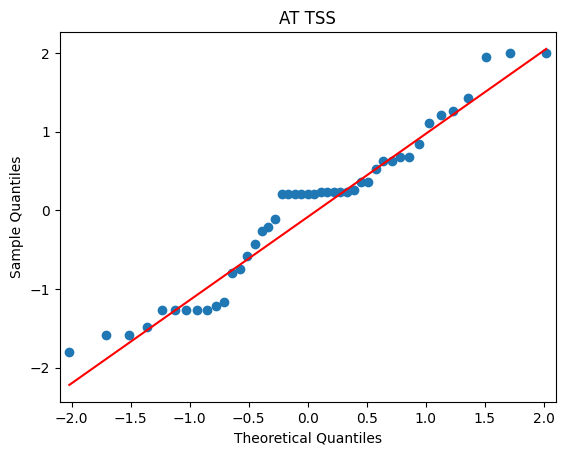

In [208]:
# Clean all unneeded experiment data 
twanova_df = pd.DataFrame(data_helper.filter(merged_df, time = [12]))
twanova_df.drop(twanova_df[twanova_df["EXPERIMENT_NAME"] == "SC"].index, inplace = True)
twanova_df.drop(twanova_df[twanova_df["EXPERIMENT_NAME"] == "CC"].index, inplace = True)
twanova_df.drop(twanova_df[twanova_df["EXPERIMENT_NAME"] == "RM"].index, inplace = True)
twanova_df.drop(twanova_df[twanova_df["EXPERIMENT_NAME"] == "BM"].index, inplace = True)

# Through all experiments
for exp in twanova_df["EXPERIMENT_NAME"].unique():
    sub_df = twanova_df[twanova_df["EXPERIMENT_NAME"] == exp]
    # For all methods
    for index in range(4, len(sub_df.columns)):
        current_anovaset = sub_df.iloc[:, [0,1,2,3, index]]
        current_exp = current_anovaset["EXPERIMENT_NAME"].iloc[0]
        method = "_".join(current_anovaset.columns[4].split("_")[:-1]) # save current method name
        current_anovaset.columns = ["ID", "EXPERIMENT_NAME", "SAMPLE_NAME", "TIME", "TREATMENT"] # rename treatment column
        
        # Test normal distribution in qqplot
        plot_helper.visualize_qqplot(title = current_exp + " " + method, data = current_anovaset["TREATMENT"])
        # Perform two-way ANOVA
        model = ols('TREATMENT ~ C(SAMPLE_NAME) + C(TIME) + C(SAMPLE_NAME):C(TIME)', data = current_anovaset).fit()
        tw_result = sm.stats.anova_lm(model, typ=2)
        # Insert meta information into result table
        new_col = [method, "Time", "Treatment:Time", "Residual"]
        tw_result.insert(0, column = (current_exp + "-Treatment"), value = new_col)
        tw_result["F"] = tw_result["F"].apply(lambda x: f"{x:.2f}")
        
        # Export to raw data to csv-file
        file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/Two-Way-ANOVA-Data.csv")
        tw_result.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a")
print("All Physiology_Two-Way-ANOVAs were performed.")

# Two-Way ANOVA RM Experiment

In [ ]:
# Clean all unneeded experiment data 
twanova_df = pd.DataFrame(data_helper.filter(merged_df, time = [12]))
twanova_df.drop(twanova_df[twanova_df["SAMPLE_NAME"] == "+EPS"].index, inplace = True)

rm_exp = twanova_df[twanova_df["EXPERIMENT_NAME"] == "RM"]
for index in range(4, len(rm_exp.columns)):
    # TW_df MMCvsdH2O
    con_con = pd.DataFrame(rm_exp)
    con_con.drop(con_con[con_con["SAMPLE_NAME"] == "AT"].index, inplace = True)
    con_con.drop(con_con[con_con["SAMPLE_NAME"] == "ET"].index, inplace = True)
    # Subset data and rename current method to TREATMENT for ANOVA structure
    cur_set = con_con.iloc[:, [0,1,2,3, index]]
    current_exp = cur_set["EXPERIMENT_NAME"].iloc[0]
    method = "_".join(cur_set.columns[4].split("_")[:-1]) # save current method name
    cur_set.columns = ["ID", "EXPERIMENT_NAME", "SAMPLE_NAME", "TIME", "TREATMENT"] # rename treatment column
    
    # Test normal distribution in qqplot
    plot_helper.visualize_qqplot(title = current_exp + " " + method, data = cur_set["TREATMENT"])
    # Perform two-way ANOVA
    model = ols('TREATMENT ~ C(SAMPLE_NAME) + C(TIME) + C(SAMPLE_NAME):C(TIME)', data = cur_set).fit()
    tw_rm_result = sm.stats.anova_lm(model, typ=2)
    # Insert meta information into result table
    new_col = [method, "Time", "Treatment:Time", "Residual"]
    tw_rm_result.insert(0, column = (current_exp + "-MMCvsdH2O"), value = new_col)
    tw_rm_result["F"] = tw_rm_result["F"].apply(lambda x: f"{x:.2f}")
    
    # Export to raw data to csv-file
    file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/Two-Way-ANOVA-Data.csv")
    tw_rm_result.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a")
    
    # TW_df dH2OvsTreatments
    con_treat = pd.DataFrame(rm_exp)
    con_treat.drop(con_treat[con_treat["SAMPLE_NAME"] == "Control"].index, inplace = True)
    # Subset data and rename current method to TREATMENT for ANOVA structure
    cur_set = con_treat.iloc[:, [0,1,2,3, index]]
    current_exp = cur_set["EXPERIMENT_NAME"].iloc[0]
    method = "_".join(cur_set.columns[4].split("_")[:-1]) # save current method name
    cur_set.columns = ["ID", "EXPERIMENT_NAME", "SAMPLE_NAME", "TIME", "TREATMENT"] # rename treatment column
    
    # Test normal distribution in qqplot
    plot_helper.visualize_qqplot(title = current_exp + " " + method, data = cur_set["TREATMENT"])
    # Perform two-way ANOVA
    model = ols('TREATMENT ~ C(SAMPLE_NAME) + C(TIME) + C(SAMPLE_NAME):C(TIME)', data = cur_set).fit()
    tw_rm_result = sm.stats.anova_lm(model, typ=2)
    # Insert meta information into result table
    new_col = [method, "Time", "Treatment:Time", "Residual"]
    tw_rm_result.insert(0, column = (current_exp + "-dH2OvsTreatments"), value = new_col)
    tw_rm_result["F"] = tw_rm_result["F"].apply(lambda x: f"{x:.2f}")
    
    # Export to raw data to csv-file
    file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/Two-Way-ANOVA-Data.csv")
    tw_rm_result.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a") 

QQ-Plot "RM RRATE" created and saved.
QQ-Plot "RM RRATE" created and saved.
QQ-Plot "RM MEAN_SVELO" created and saved.
QQ-Plot "RM MEAN_SVELO" created and saved.
QQ-Plot "RM MEAN_PARSIZE" created and saved.
QQ-Plot "RM MEAN_PARSIZE" created and saved.
QQ-Plot "RM TSS" created and saved.
QQ-Plot "RM TSS" created and saved.
QQ-Plot "RM TSS" created and saved.
QQ-Plot "RM TSS" created and saved.
QQ-Plot "RM VSS" created and saved.
QQ-Plot "RM VSS" created and saved.
QQ-Plot "RM VSS" created and saved.
QQ-Plot "RM VSS" created and saved.
QQ-Plot "RM ZETA_POTENTIAL" created and saved.
QQ-Plot "RM ZETA_POTENTIAL" created and saved.


# Two-Way ANOVA BM Experiment

In [ ]:
# Clean all unneeded experiment data 
twanova_df = pd.DataFrame(data_helper.filter(merged_df, time = [12]))

bm_exp = twanova_df[twanova_df["EXPERIMENT_NAME"] == "BM"]
for index in range(4, len(bm_exp.columns)):
    # TW_df MMCvsAMC
    mmc_amc = pd.DataFrame(bm_exp)
    mmc_amc.drop(mmc_amc[mmc_amc["SAMPLE_NAME"] == "CoC"].index, inplace = True)
    mmc_amc.drop(mmc_amc[mmc_amc["SAMPLE_NAME"] == "EPS"].index, inplace = True)
    # Subset data and rename current method to TREATMENT for ANOVA structure
    cur_set = mmc_amc.iloc[:, [0,1,2,3, index]]
    current_exp = cur_set["EXPERIMENT_NAME"].iloc[0]
    method = "_".join(cur_set.columns[4].split("_")[:-1]) # save current method name
    cur_set.columns = ["ID", "EXPERIMENT_NAME", "SAMPLE_NAME", "TIME", "TREATMENT"] # rename treatment column
    
    # Test normal distribution in qqplot
    plot_helper.visualize_qqplot(title = current_exp + " " + method, data = cur_set["TREATMENT"])
    # Perform two-way ANOVA
    model = ols('TREATMENT ~ C(SAMPLE_NAME) + C(TIME) + C(SAMPLE_NAME):C(TIME)', data = cur_set).fit()
    tw_bm_result = sm.stats.anova_lm(model, typ=2)
    # Insert meta information into result table
    new_col = [method, "Time", "Treatment:Time", "Residual"]
    tw_bm_result.insert(0, column = (current_exp + "-MMCvsAMC"), value = new_col)
    tw_bm_result["F"] = tw_bm_result["F"].apply(lambda x: f"{x:.2f}")
    
    # Export to raw data to csv-file
    file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/Two-Way-ANOVA-Data.csv")
    tw_bm_result.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a")
    
    # TW_df CoCvsEPS
    coc_eps = pd.DataFrame(bm_exp)
    coc_eps.drop(coc_eps[coc_eps["SAMPLE_NAME"] == "AMC"].index, inplace = True)
    coc_eps.drop(coc_eps[coc_eps["SAMPLE_NAME"] == "CoA"].index, inplace = True)
    # Subset data and rename current method to TREATMENT for ANOVA structure
    cur_set = coc_eps.iloc[:, [0,1,2,3, index]]
    current_exp = cur_set["EXPERIMENT_NAME"].iloc[0]
    method = "_".join(cur_set.columns[4].split("_")[:-1]) # save current method name
    cur_set.columns = ["ID", "EXPERIMENT_NAME", "SAMPLE_NAME", "TIME", "TREATMENT"] # rename treatment column
    
    # Test normal distribution in qqplot
    plot_helper.visualize_qqplot(title = current_exp + " " + method, data = cur_set["TREATMENT"])
    # Perform two-way ANOVA
    model = ols('TREATMENT ~ C(SAMPLE_NAME) + C(TIME) + C(SAMPLE_NAME):C(TIME)', data = cur_set).fit()
    tw_bm_result = sm.stats.anova_lm(model, typ=2)
    # Insert meta information into result table
    new_col = [method, "Time", "Treatment:Time", "Residual"]
    tw_bm_result.insert(0, column = (current_exp + "-CoCvsEPS"), value = new_col)
    tw_bm_result["F"] = tw_bm_result["F"].apply(lambda x: f"{x:.2f}")
    
    # Export to raw data to csv-file
    file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/Two-Way-ANOVA-Data.csv")
    tw_bm_result.to_csv(file_name, encoding = "utf-8", index = False, header = True, mode = "a") 

QQ-Plot "BM RRATE" created and saved.
QQ-Plot "BM RRATE" created and saved.
QQ-Plot "BM MEAN_SVELO" created and saved.
QQ-Plot "BM MEAN_SVELO" created and saved.
QQ-Plot "BM MEAN_PARSIZE" created and saved.
QQ-Plot "BM MEAN_PARSIZE" created and saved.
QQ-Plot "BM TSS" created and saved.
QQ-Plot "BM TSS" created and saved.
QQ-Plot "BM TSS" created and saved.
QQ-Plot "BM TSS" created and saved.
QQ-Plot "BM VSS" created and saved.
QQ-Plot "BM VSS" created and saved.
QQ-Plot "BM VSS" created and saved.
QQ-Plot "BM VSS" created and saved.
QQ-Plot "BM ZETA_POTENTIAL" created and saved.
QQ-Plot "BM ZETA_POTENTIAL" created and saved.


# Average Replicates (Obsolet)

In [ ]:
# Calculate mean of triplicates
mean_df = merged_df.groupby(["EXPERIMENT_NAME", "SAMPLE_NAME", "TIME"], as_index = False).agg({"RRATE_%": pd.Series.mean, 
                                                                                               "MEAN_SVELO_M/H": pd.Series.mean, 
                                                                                               "MEAN_PARSIZE_µM": pd.Series.mean, 
                                                                                               "TSS_g/L": pd.Series.mean, 
                                                                                               "TSS_%": pd.Series.mean,
                                                                                               "VSS_g/L": pd.Series.mean, 
                                                                                               "VSS_%": pd.Series.mean,
                                                                                               "ZETA_POTENTIAL_MV": pd.Series.mean,
                                                                                               })
mean_df = mean_df.round(2)

# Export to raw data to csv-file
file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/Averaged-Data.csv")
mean_df.to_csv(file_name, encoding = "utf-8", index = False)

print("Averaged replicates into one value.")

Averaged replicates into one value.


# Standard Deviation Triplicates (Obsolet)

In [ ]:
# Calculate standard deviation of triplicates
stdev_df = merged_df.groupby(["EXPERIMENT_NAME", "SAMPLE_NAME", "TIME"], as_index = False).agg({"RRATE_%": pd.Series.std, 
                                                                                               "MEAN_SVELO_M/H": pd.Series.std, 
                                                                                               "MEAN_PARSIZE_µM": pd.Series.std, 
                                                                                               "TSS_g/L": pd.Series.std, 
                                                                                               "TSS_%": pd.Series.std,
                                                                                               "VSS_g/L": pd.Series.std, 
                                                                                               "VSS_%": pd.Series.std,
                                                                                               "ZETA_POTENTIAL_MV": pd.Series.std,
                                                                                               })
stdev_df = stdev_df.round(2)

# Export to raw data to csv-file
file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Data-Statistics/Standard-Deviated-Data.csv")
stdev_df.to_csv(file_name, encoding = "utf-8", index = False)

print("Calculated standard deviation for raw data.")

Calculated standard deviation for raw data.


# Post-Hoc Test

In [226]:
# Function for method name check
def check_methodname(abbr_name):
    if abbr_name == "RRATE_%":
        full_name = "Recovery Rate [%]"
    elif abbr_name == "MEAN_SVELO_M/H":
        full_name = "Sinking Velocity [m h-1]"    
    elif abbr_name == "MEAN_PARSIZE_ÂµM":
        full_name = "Particle Size [µm]"
    elif abbr_name == "ZETA_POTENTIAL_MV":
        full_name = "Zeta Potential [mV]"
    else:
        full_name = abbr_name
    return full_name

def format_cell(x):
    try:
        num = float(x)
        return f"{num:.2f}"
    except:
        return f"{num:.2f}"  # Wenn es keine Zahl ist, bleibt es wie es ist

In [231]:
# Post-Hoc Test All Experiments

# Delete old file if exists
file = data_helper.get_output_path(CONFIG, "Raw-Data/Paper_Data-Statistics/PostHoc-Data.csv")
if(os.path.exists(file) and os.path.isfile(file)): 
  os.remove(file) 
  print("Old file deleted.") 
else: 
  print("File not found.")

# Get custom data frame with correct sorted samples (CAREFUL, no automated data handling here!)
posthoc_df = pd.read_csv(data_helper.get_output_path(CONFIG, "Raw-Data/Paper_Data-Statistics/custom_merged_df.csv"), index_col=0, encoding='unicode_escape')

# iterate through all unique experiments
for exp in posthoc_df["EXPERIMENT_NAME"].unique():
    sub_df = posthoc_df[posthoc_df["EXPERIMENT_NAME"] == exp]
    # For all methods
    for index in range(4, len(sub_df.columns)):
        current_sampleset = sub_df.iloc[:, [0,1,2,3, index]]
        current_exp = current_sampleset["EXPERIMENT_NAME"].iloc[0]
        method = current_sampleset.columns[4] # save current method name
        
        # For all timepoints
        for unique_time in current_sampleset["TIME"].unique(): 
            current_timeset = current_sampleset[current_sampleset["TIME"] == unique_time]
           
            # PostHoc-Tests / Table Creation
            posthoc_result = sp.posthoc_tukey(current_timeset, val_col=method, group_col='SAMPLE_NAME')
            posthoc_result = posthoc_result.map(lambda x: f"{x:.2f}" if pd.notnull(x) else "")
            
            # Sample Information Column
            sub_meta = META_DATA[META_DATA["EXP_ABBR"] == exp][:1].reset_index()
            sample_count = len(current_sampleset["SAMPLE_NAME"].unique())
            sample_information = [sub_meta["EXP_FULL"][0], check_methodname(method), str(unique_time) + " h"]
            # Match Rows of Sample Information for each Experiment and its Samples
            if sample_count > len(sample_information):
                difference = sample_count - len(sample_information)
                for filler in range(0, difference):
                    sample_information.append("")
            # Insert Information at the end
            posthoc_result.insert(len(posthoc_result), column = "Sample Information", value = sample_information)
            
            # File Export
            file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Paper_Data-Statistics/PostHoc-Data.csv")
            posthoc_result.to_csv(file_name, encoding = "utf-8-sig", index = True, header = True, mode = "a", float_format="%.2f")
            
print("New file created.") 

Old file deleted.
New file created.


# Sample Data + ConfInt

### Confidence Intervalle für gesamten Datenframe berechnen 

In [ ]:
# Beispielhafte Aggregationsfunktion, die das 95%-Konfidenzintervall zurückgibt
def ci95(x):
    ci_low, ci_high = sms.DescrStatsW(x).tconfint_mean()
    return pd.Series({'CI95': f"{ci_low:.2f}" + ", " + f"{ci_high:.2f}"})

# Deine Messwerte-Gruppierung
group_cols = ["EXPERIMENT_NAME", "SAMPLE_NAME", "TIME"]
value_cols = [
    "RRATE_%", "MEAN_SVELO_M/H", "MEAN_PARSIZE_µM", "TSS_g/L", "TSS_%",
    "VSS_g/L", "VSS_%", "ZETA_POTENTIAL_MV"
]

# Leere Liste für alle CI-DataFrames
ci_frames = []

for col in value_cols:
    # Gruppieren und CI berechnen
    ci = merged_df.groupby(group_cols)[col].apply(ci95).unstack()
    # Umbenennen der Spalten mit dem Messnamen als Prefix
    ci.columns = [f"{col}"]
    ci_frames.append(ci)

# Alles zusammenfügen
ci_df = pd.concat(ci_frames, axis=1).reset_index()

# Ausgabe: ci_df enthält alle Konfidenzintervalle pro Gruppe
print(ci_df.head())

  EXPERIMENT_NAME SAMPLE_NAME  TIME        RRATE_% MEAN_SVELO_M/H  \
0              AT         0.1     0   77.71, 97.59     1.11, 3.99   
1              AT         0.1    24  48.87, 117.36     0.92, 2.17   
2              AT         0.1    48  67.27, 106.43     0.25, 2.76   
3              AT           1     0   77.71, 97.59     1.11, 3.99   
4              AT           1    24  70.11, 105.27    -0.01, 3.39   

    MEAN_PARSIZE_µM     TSS_g/L          TSS_%      VSS_g/L         VSS_%  \
0   332.93, 1228.79  0.96, 1.50   93.71, 96.14   0.06, 0.06    3.86, 6.29   
1    295.28, 729.53  1.20, 1.36   91.91, 96.70   0.04, 0.11    3.30, 8.09   
2     93.86, 767.33  1.07, 1.65  80.68, 104.40  -0.07, 0.28  -4.40, 19.32   
3   332.93, 1228.79  0.96, 1.50   93.71, 96.14   0.06, 0.06    3.86, 6.29   
4  -185.66, 1108.04  1.02, 1.54  90.80, 100.27  -0.01, 0.12   -0.27, 9.20   

  ZETA_POTENTIAL_MV  
0     -49.76, -6.13  
1    -29.38, -15.20  
2    -22.71, -20.98  
3     -49.76, -6.13  
4    -35.78,

### Merge Mean, StDev, CI into one string-based Dataframe

In [ ]:
export_mean_df = mean_df
export_stdev_df = stdev_df
export_ci_df = ci_df 

# Step 3: Gemeinsame Spalten beibehalten
common_cols = ['EXPERIMENT_NAME', 'SAMPLE_NAME', 'TIME']
treatment_cols = [col for col in export_mean_df.columns if col not in common_cols]

# Step 4: Neue DataFrame vorbereiten
combined_df = export_mean_df[common_cols].copy()

# Step 5: Behandlung der Treatment-Werte im gewünschten Format (Forced 2 Nachkommastellen)
for col in treatment_cols:
    combined_df[col] = export_mean_df[col].apply(lambda x: f"{x:.2f}") + " ± " + export_stdev_df[col].apply(lambda x: f"{x:.2f}") + " [95% CI: " + export_ci_df[col] + "]"


# Export confint to csv-file (append)
file_name = data_helper.get_output_path(CONFIG, "Raw-Data/Paper_Data-Statistics/Sample-Data-With-CI95.csv")
combined_df.to_csv(file_name, encoding = "utf-8-sig", index = False, header = True, mode = "w")

combined_df.head(1)

,EXPERIMENT_NAME,SAMPLE_NAME,TIME,RRATE_%,MEAN_SVELO_M/H,MEAN_PARSIZE_µM,TSS_g/L,TSS_%,VSS_g/L,VSS_%,ZETA_POTENTIAL_MV
0,AT,0.1,0,"87.65 ± 4.00 [95% CI: 77.71, 97.59]","2.55 ± 0.58 [95% CI: 1.11, 3.99]","780.86 ± 180.31 [95% CI: 332.93, 1228.79]","1.23 ± 0.11 [95% CI: 0.96, 1.50]","94.92 ± 0.49 [95% CI: 93.71, 96.14]","0.06 ± 0.00 [95% CI: 0.06, 0.06]","5.08 ± 0.49 [95% CI: 3.86, 6.29]","-27.94 ± 8.78 [95% CI: -49.76, -6.13]"
